In [1]:
!pip install tensorflow
import tensorflow as tf
print(tf.__version__)

2.20.0


In [2]:
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
mnist = keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


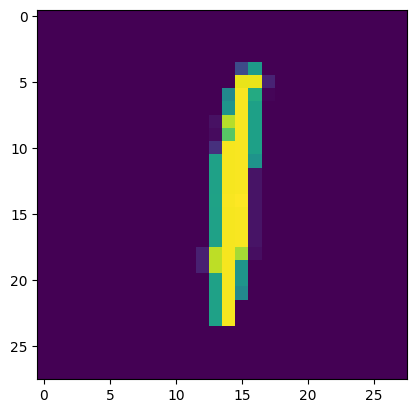

In [4]:
!pip install matplotlib
import matplotlib.pyplot as plt
plt.imshow(x_train[112])

In [5]:
x_train.shape

(60000, 28, 28)

In [6]:
x_test.shape

(10000, 28, 28)

In [7]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28,1)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
history = model.fit(x_train, y_train, validation_split=0.1, epochs=10)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9219 - loss: 0.2745 - val_accuracy: 0.9615 - val_loss: 0.1309
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9650 - loss: 0.1208 - val_accuracy: 0.9713 - val_loss: 0.0995
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9754 - loss: 0.0813 - val_accuracy: 0.9763 - val_loss: 0.0839
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9814 - loss: 0.0618 - val_accuracy: 0.9783 - val_loss: 0.0756
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9858 - loss: 0.0473 - val_accuracy: 0.9782 - val_loss: 0.0774
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9883 - loss: 0.0373 - val_accuracy: 0.9782 - val_loss: 0.0730
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9911 - loss: 0.0287 - val_accuracy: 0.9798 - val_loss: 0.0770
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9922 - loss: 0.0248

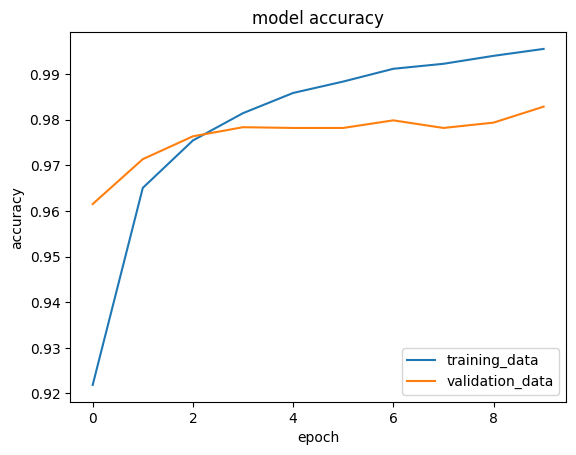

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training_data', 'validation_data'], loc='lower right')
plt.show()

In [11]:
y_pred=model.predict(x_test)
y_pred[8888]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([1.0397191e-09, 1.2686774e-12, 5.5725784e-09, 8.6530241e-11,
       5.3988833e-07, 7.4210950e-12, 9.9999934e-01, 4.9206109e-15,
       5.7182275e-12, 1.3639611e-16], dtype=float32)

In [12]:
import numpy as np
y_pred1=np.argmax(y_pred,axis=1)
y_pred1[8888]

np.int64(6)

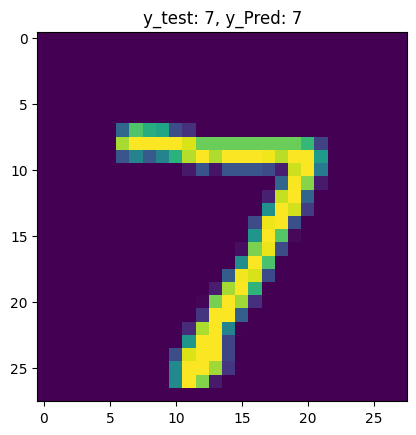

In [13]:
digit = 7
indices = np.where((y_test == digit) & (y_pred1 == digit))[0]
idx = indices[0]

plt.imshow(x_test[idx].reshape(28,28))
plt.title(f"y_test: {y_test[idx]}, y_Pred: {y_pred1[idx]}")
plt.show()

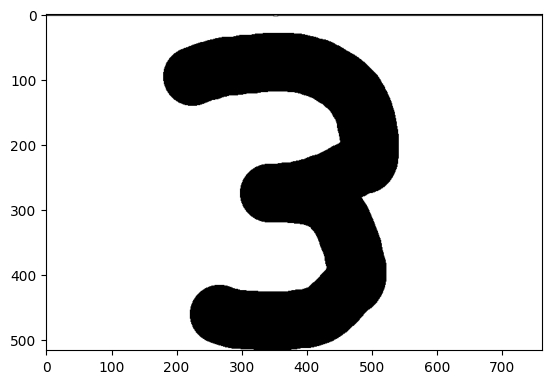

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("/content/Screenshot 2026-06-04 210558.png", cv2.IMREAD_GRAYSCALE)

# Invert so digit becomes white
img_inv = 255 - img

# Find non-zero pixels
coords = cv2.findNonZero(img_inv)

# Bounding box around digit
x, y, w, h = cv2.boundingRect(coords)

# Crop digit
digit = img[y:y+h, x:x+w]

plt.imshow(digit, cmap='gray')
plt.show()

In [20]:
digit = cv2.resize(digit, (28,28))
digit = 255 - digit
digit = digit / 255.0

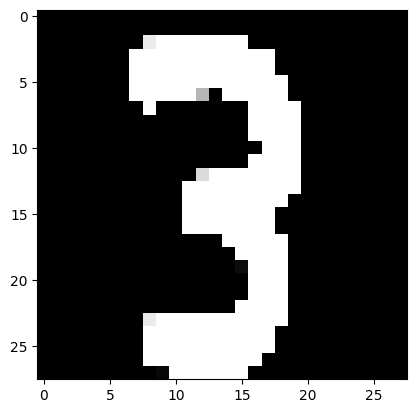

In [21]:
plt.imshow(digit, cmap='gray')
plt.show()

In [22]:
digit_input = digit.reshape(1,28,28)
pred = model.predict(digit_input)
print("Predicted:", np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted: 3


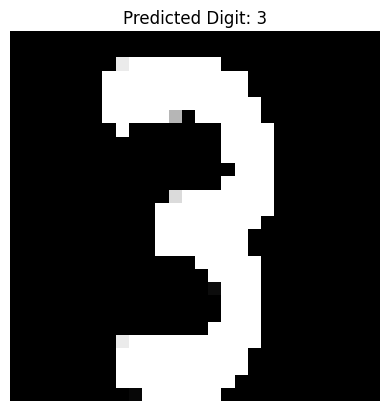

In [23]:
plt.imshow(digit.reshape(28,28), cmap='gray')
plt.title(f"Predicted Digit: {np.argmax(pred)}")
plt.axis('off')
plt.show()

In [24]:
model.save('dp_model.h5')

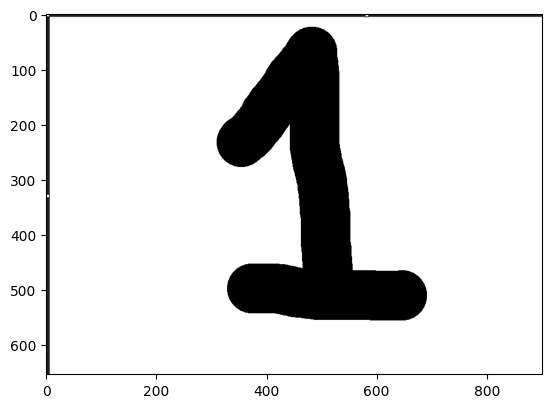

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("/content/Screenshot 2026-06-04 210438.png", cv2.IMREAD_GRAYSCALE)

# Invert so digit becomes white
img_inv = 255 - img

# Find non-zero pixels
coords = cv2.findNonZero(img_inv)

# Bounding box around digit
x, y, w, h = cv2.boundingRect(coords)

# Crop digit
digit = img[y:y+h, x:x+w]

plt.imshow(digit, cmap='gray')
plt.show()

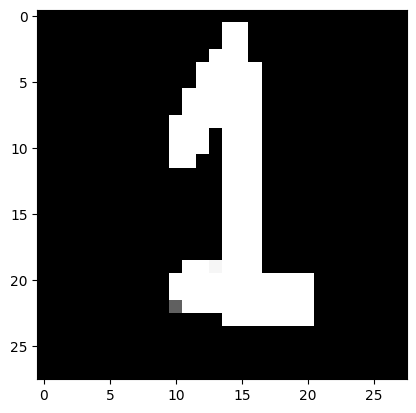

In [37]:
digit = cv2.resize(digit, (28,28))
digit = 255 - digit
digit = digit / 255.0
plt.imshow(digit, cmap='gray')
plt.show()

In [38]:
digit_input = digit.reshape(1,28,28)
pred = model.predict(digit_input)
print("Predicted:", np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted: 1


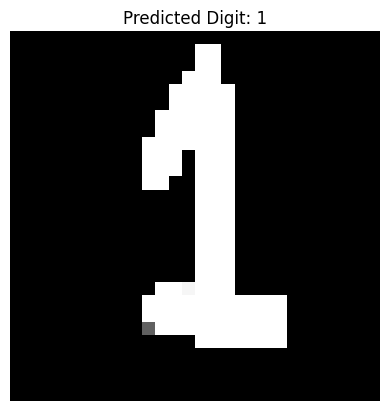

In [39]:
plt.imshow(digit.reshape(28,28), cmap='gray')
plt.title(f"Predicted Digit: {np.argmax(pred)}")
plt.axis('off')
plt.show()

In [40]:
pred = model.predict(digit_input)

for i, p in enumerate(pred[0]):
    print(f"{i}: {p:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
0: 0.0000
1: 1.0000
2: 0.0000
3: 0.0000
4: 0.0000
5: 0.0000
6: 0.0000
7: 0.0000
8: 0.0000
9: 0.0000
